In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model

print("TensorFlow:", tf.__version__)

2025-11-14 04:23:47.183810: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763074427.197742  278308 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763074427.202208  278308 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763074427.214734  278308 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763074427.214757  278308 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763074427.214759  278308 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0


In [2]:
train_df = pd.read_csv("dataset/train.csv")
test_df  = pd.read_csv("dataset/test.csv")

display(train_df.head())
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


Train shape: (1785, 9)
Test shape: (5, 3)


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
# groups = train_df["sample_id"]
groups = train_df["image_path"]

train_idx, val_idx = next(gss.split(train_df, groups=groups))

train_split = train_df.iloc[train_idx].reset_index(drop=True)
val_split   = train_df.iloc[val_idx].reset_index(drop=True)

train_split.to_csv("train_split.csv", index=False)
val_split.to_csv("val_split.csv", index=False)

print("Train rows:", len(train_split))
print("Val rows:", len(val_split))

Train rows: 1428
Val rows: 357


In [4]:
ndvi_mean   = train_df["Pre_GSHH_NDVI"].mean()
ndvi_std    = train_df["Pre_GSHH_NDVI"].std(ddof=0)

height_mean = train_df["Height_Ave_cm"].mean()
height_std  = train_df["Height_Ave_cm"].std(ddof=0)

tmp_month = pd.to_datetime(train_df["Sampling_Date"]).dt.month.fillna(6)
month_mean = tmp_month.mean()
month_std  = tmp_month.std(ddof=0)


In [ ]:
train_split = pd.read_csv("train_split.csv")
val_split   = pd.read_csv("val_split.csv")

def normalize(col, mean, std):
    return (col - mean) / (std if std != 0 else 1)

# numeric fields
def process_df(df):
    df = df.copy()
    df['ndvi']   = normalize(df['Pre_GSHH_NDVI'].astype(float), ndvi_mean, ndvi_std)
    df['height'] = normalize(df['Height_Ave_cm'].astype(float), height_mean, height_std)
    df['month']  = normalize(
        pd.to_datetime(df["Sampling_Date"]).dt.month.fillna(6).astype(int),
        month_mean, month_std
    )
    return df

train_split = process_df(train_split)
val_split   = process_df(val_split)

# one-hot categories (consistent)
state_cols_full   = pd.get_dummies(train_df["State"]).columns
species_cols_full = pd.get_dummies(train_df["Species"]).columns
target_order      = ['Dry_Clover_g','Dry_Dead_g','Dry_Green_g','Dry_Total_g','GDM_g']

def onehot(df, cols, key):
    return pd.get_dummies(df[key]).reindex(columns=cols).fillna(0).values

# build metadata arrays IN EXACT ROW ORDER
def build_meta(df):
    state   = onehot(df, state_cols_full, "State")
    species = onehot(df, species_cols_full, "Species")

    return np.hstack([
        df["ndvi"].values.reshape(-1,1),
        df["height"].values.reshape(-1,1),
        df["month"].values.reshape(-1,1),
        state,
        species
    ])

meta_train = build_meta(train_split)
meta_val   = build_meta(val_split)

# target types (one-hot)
tt_train = pd.get_dummies(train_split["target_name"]).reindex(columns=target_order).fillna(0).values
tt_val   = pd.get_dummies(val_split["target_name"]).reindex(columns=target_order).fillna(0).values

# target values
y_train = train_split["target"].astype(float).values
y_val   = val_split["target"].astype(float).values

print("meta_train:", meta_train.shape)
print("tt_train:", tt_train.shape)
print("y_train:",  y_train.shape)


meta_train: (1428, 22)
tt_train: (1428, 5)
y_train: (1428,)


In [11]:
IMG_SIZE = 384
BATCH = 12

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

def create_dataset(df, meta, tt, targets):
    paths = "dataset/" + df["image_path"]

    ds = tf.data.Dataset.from_tensor_slices((
        paths.values,
        meta.astype(np.float32),
        tt.astype(np.float32),
        targets.astype(np.float32)
    ))

    def load_row(path, m, ttype, target):
        img = load_image(path)
        return (
            {
                "image_input": img,
                "meta_input":  m,
                "target_type": ttype
            },
            target
        )

    ds = ds.map(load_row, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(1024).batch(BATCH).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_split, meta_train, tt_train, y_train)
val_ds   = create_dataset(val_split, meta_val, tt_val, y_val)

train_ds, val_ds


(<_PrefetchDataset element_spec=({'image_input': TensorSpec(shape=(None, 384, 384, 3), dtype=tf.float32, name=None), 'meta_input': TensorSpec(shape=(None, 22), dtype=tf.float32, name=None), 'target_type': TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)}, TensorSpec(shape=(None,), dtype=tf.float32, name=None))>,
 <_PrefetchDataset element_spec=({'image_input': TensorSpec(shape=(None, 384, 384, 3), dtype=tf.float32, name=None), 'meta_input': TensorSpec(shape=(None, 22), dtype=tf.float32, name=None), 'target_type': TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)}, TensorSpec(shape=(None,), dtype=tf.float32, name=None))>)

In [ ]:
from tensorflow.keras import layers, Model


def conv_block(x, filters, kernel=3):
    x = layers.Conv2D(filters, kernel, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def depthwise_block(x, filters):
    x = layers.SeparableConv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def residual_block(x, filters):
    shortcut = layers.Conv2D(filters, 1, padding='same')(x)

    x = depthwise_block(x, filters)
    x = depthwise_block(x, filters)
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x

def se_block(x, reduction=16):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // reduction, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.Multiply()([x, se])

# ------------------------------------------------------------
# IMAGE INPUT BRANCH (STRONG CNN)
# ------------------------------------------------------------
input_img_size = 384    
image_input = layers.Input(shape=(input_img_size, input_img_size, 3), name="image_input")

x = conv_block(image_input, 32)
x = residual_block(x, 32)
x = layers.MaxPooling2D(2)(x)

x = conv_block(x, 64)
x = residual_block(x, 64)
x = layers.MaxPooling2D(2)(x)

x = conv_block(x, 128)
x = residual_block(x, 128)
x = layers.MaxPooling2D(2)(x)

x = conv_block(x, 256)
x = residual_block(x, 256)
x = layers.MaxPooling2D(2)(x)

x = conv_block(x, 512)
x = residual_block(x, 512)

# Squeeze-and-Excitation for better feature calibration
x = se_block(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)

image_features = layers.Dense(512, activation='relu')(x)   # stronger head
image_features = layers.Dropout(0.25)(image_features)

# ------------------------------------------------------------
# METADATA BRANCH
# ------------------------------------------------------------

meta_input = layers.Input(shape=(meta_train.shape[1],), name="meta_input")

m = layers.Dense(128, activation='relu')(meta_input)
m = layers.BatchNormalization()(m)
m = layers.Dense(64, activation='relu')(m)
m = layers.Dense(32, activation='relu')(m)

# ------------------------------------------------------------
# TARGET-TYPE BRANCH
# ------------------------------------------------------------

target_input = layers.Input(shape=(tt_train.shape[1],), name="target_type")

t = layers.Dense(32, activation='relu')(target_input)
t = layers.Dense(16, activation='relu')(t)

# ------------------------------------------------------------
# FUSION
# ------------------------------------------------------------

combined = layers.Concatenate()([image_features, m, t])

h = layers.Dense(512, activation='relu')(combined)
h = layers.Dropout(0.3)(h)

h = layers.Dense(256, activation='relu')(h)
h = layers.BatchNormalization()(h)

h = layers.Dense(128, activation='relu')(h)
h = layers.Dropout(0.2)(h)

h = layers.Dense(64, activation='relu')(h)

output = layers.Dense(1)(h)

model = Model(inputs=[image_input, meta_input, target_input], outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="mse",
    metrics=["mae"]
)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 384, 384,  │        864 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 384, 384,  │        128 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_60 (ReLU)     │ (None, 384, 384,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_30 │ (None, 384, 384,  │      1,312 │ re_lu_60[0][0]    │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 384, 384,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_61 (ReLU)     │ (None, 384, 384,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_31 │ (None, 384, 384,  │      1,312 │ re_lu_61[0][0]    │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 384, 384,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_62 (ReLU)     │ (None, 384, 384,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 384, 384,  │      1,056 │ re_lu_60[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 384, 384,  │          0 │ re_lu_62[0][0],   │
│                     │ 32)               │            │ conv2d_31[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_63 (ReLU)     │ (None, 384, 384,  │          0 │ add_15[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 192, 192,  │          0 │ re_lu_63[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 192, 192,  │     18,432 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192, 192,  │        256 │ conv2d_32[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_64 (ReLU)     │ (None, 192, 192,  │          0 │ batch_normalizat

 Total params: 3,417,169 (13.04 MB)

 Trainable params: 3,410,449 (13.01 MB)

 Non-trainable params: 6,720 (26.25 KB)

In [17]:
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     # patience=10,
#     restore_best_weights=True
# )

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    # patience=5,
    factor=0.3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[reduce_lr],
    verbose=1
)
 

Epoch 1/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 33s 239ms/step - loss: 224.7720 - mae: 10.8108 - val_loss: 179.5885 - val_mae: 9.1752 - learning_rate: 1.0000e-04
Epoch 2/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 34s 243ms/step - loss: 212.4707 - mae: 10.6093 - val_loss: 246.6140 - val_mae: 11.0489 - learning_rate: 1.0000e-04
Epoch 3/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 34s 244ms/step - loss: 209.6118 - mae: 10.4028 - val_loss: 160.9190 - val_mae: 9.0849 - learning_rate: 1.0000e-04
Epoch 4/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 34s 244ms/step - loss: 212.9716 - mae: 10.4008 - val_loss: 166.7083 - val_mae: 8.9468 - learning_rate: 1.0000e-04
Epoch 5/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 34s 241ms/step - loss: 217.3496 - mae: 10.5359 - val_loss: 156.2865 - val_mae: 8.8612 - learning_rate: 1.0000e-04
Epoch 6/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 33s 243ms/step - loss: 187.6322 - mae: 10.0079 - val_loss: 163.8756 - val_mae: 8.8686 - learning_rate: 1.0000e-04
Epoch 7/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 34s 245ms/step - loss: 221.2700 - m

In [18]:
model.save("model4_overtrained.h5")

In [19]:
import numpy as np
import matplotlib.pyplot as plt

hist = history.history

# Extract what history contains
loss = np.array(hist["loss"])
val_loss = np.array(hist["val_loss"])
mae = np.array(hist["mae"])
val_mae = np.array(hist["val_mae"])
lr = np.array(hist["learning_rate"])

# Calculate extra metrics
rmse = np.sqrt(loss)
val_rmse = np.sqrt(val_loss)

loss0 = loss[0]  # baseline for R² computation

r2 = 1 - (loss / loss0)
val_r2 = 1 - (val_loss / loss0)

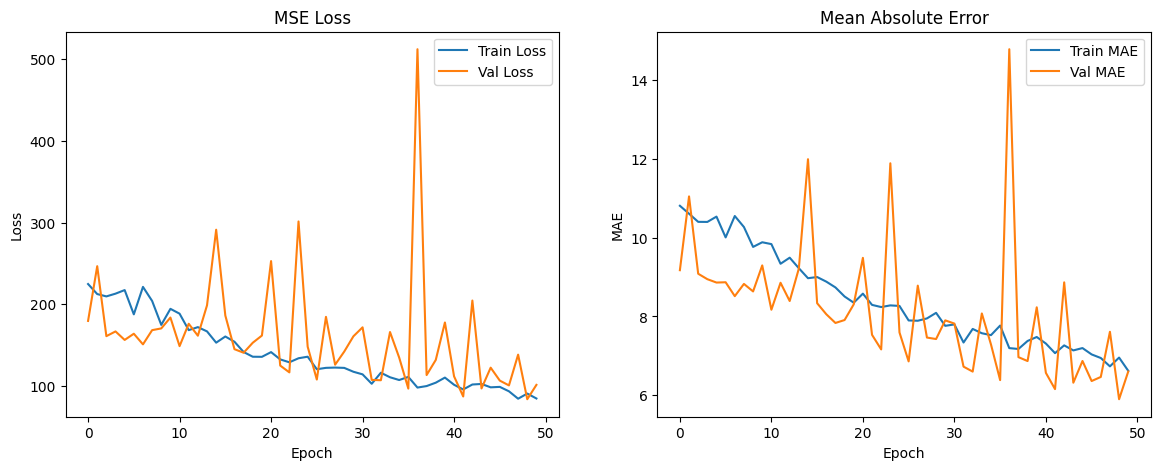

In [20]:
plt.figure(figsize=(14,5))

# LOSS
plt.subplot(1,2,1)
plt.plot(loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.title("MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# MAE
plt.subplot(1,2,2)
plt.plot(mae, label="Train MAE")
plt.plot(val_mae, label="Val MAE")
plt.title("Mean Absolute Error")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.show()


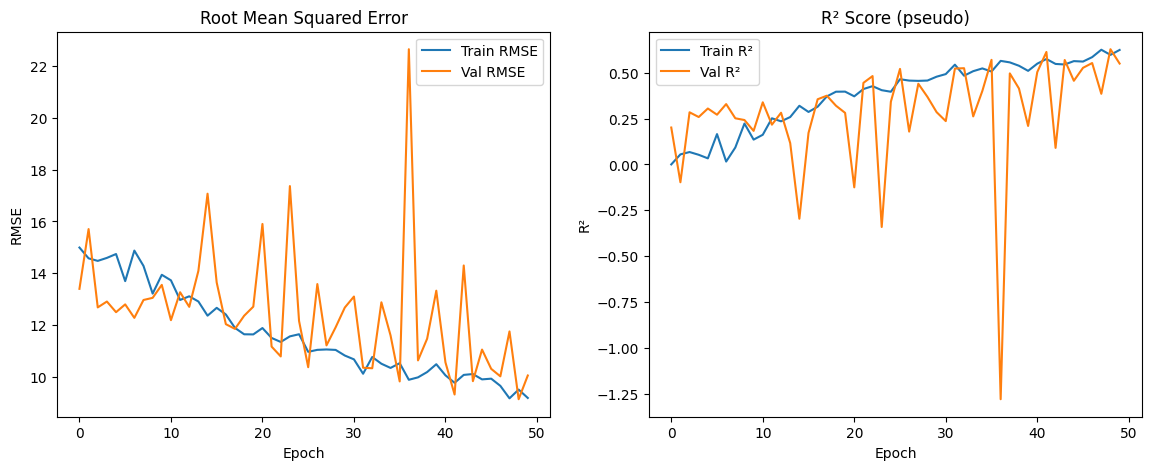

In [21]:
plt.figure(figsize=(14,5))

# RMSE
plt.subplot(1,2,1)
plt.plot(rmse, label="Train RMSE")
plt.plot(val_rmse, label="Val RMSE")
plt.title("Root Mean Squared Error")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()

# R²
plt.subplot(1,2,2)
plt.plot(r2, label="Train R²")
plt.plot(val_r2, label="Val R²")
plt.title("R² Score (pseudo)")
plt.xlabel("Epoch")
plt.ylabel("R²")
plt.legend()

plt.show()


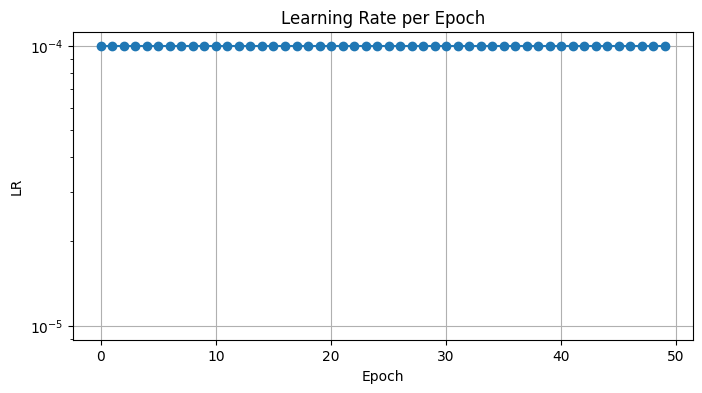

In [22]:
plt.figure(figsize=(8,4))
plt.plot(lr, marker='o')
plt.title("Learning Rate per Epoch")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.yscale("log")
plt.grid(True)
plt.show()


In [23]:
preds = model.predict(train_ds, verbose=1)
preds = preds.reshape(-1)  # flatten to (N,)
print(preds[:10])


119/119 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step
[24.402727   38.85624    14.848311   63.3992     14.111363   30.572666
 34.088985   56.105656    0.42340237 17.75083   ]


Prediction stats:
min: -0.9832297
max: 294.15387
mean: 27.518568
std: 29.92494


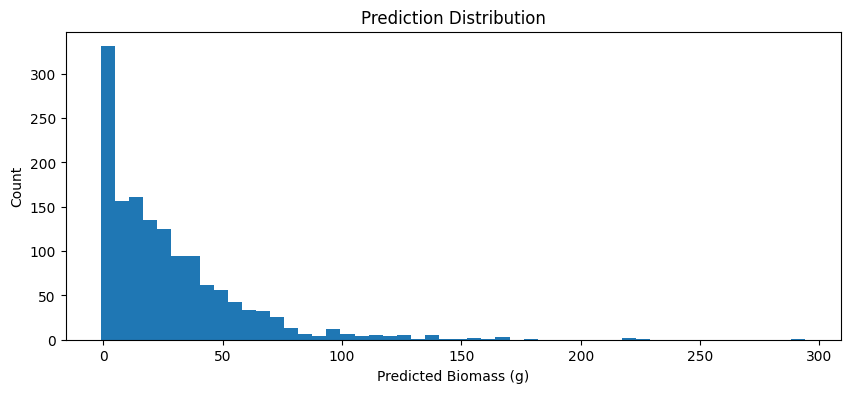

High clip threshold: 164.43468


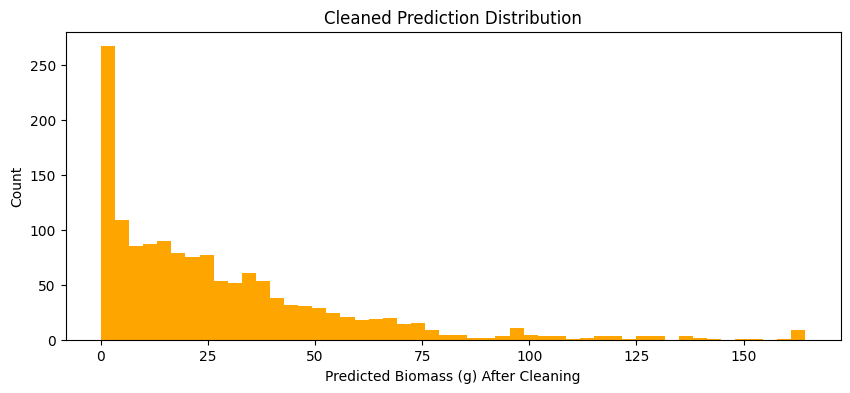

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# A. Analyze prediction distribution
# ---------------------------
print("Prediction stats:")
print("min:", preds.min())
print("max:", preds.max())
print("mean:", preds.mean())
print("std:", preds.std())

plt.figure(figsize=(10,4))
plt.hist(preds, bins=50)
plt.title("Prediction Distribution")
plt.xlabel("Predicted Biomass (g)")
plt.ylabel("Count")
plt.show()

# ---------------------------
# B. Clip NEGATIVE predictions (biomass can't be < 0)
# ---------------------------
preds = np.clip(preds, 0, None)

# ---------------------------
# C. Handle extreme OUTLIERS
# Strategy:
#   - Compute 99.5th percentile
#   - Soft-limit anything above it
# ---------------------------
high_thresh = np.percentile(preds, 99.5)
print("High clip threshold:", high_thresh)

preds[preds > high_thresh] = high_thresh

plt.figure(figsize=(10,4))
plt.hist(preds, bins=50, color='orange')
plt.title("Cleaned Prediction Distribution")
plt.xlabel("Predicted Biomass (g) After Cleaning")
plt.ylabel("Count")
plt.show()



Prediction stats:
min: -0.9832297
max: 294.15387
mean: 27.518568
std: 29.92494


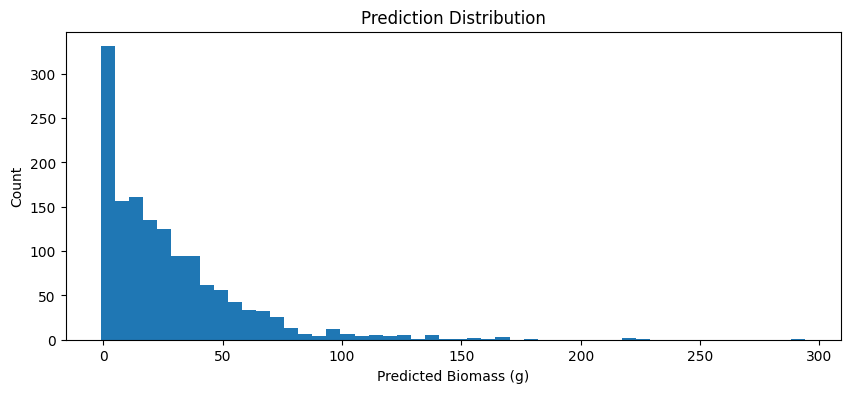

High clip threshold: 164.43468


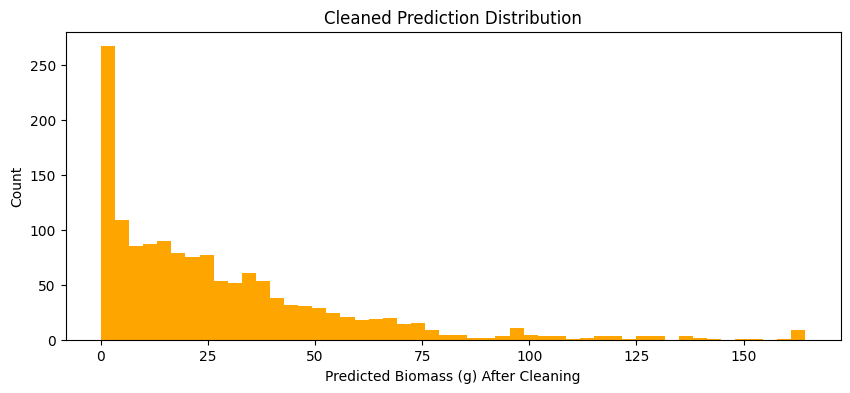

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# A. Analyze prediction distribution
# ---------------------------
print("Prediction stats:")
print("min:", preds.min())
print("max:", preds.max())
print("mean:", preds.mean())
print("std:", preds.std())

plt.figure(figsize=(10,4))
plt.hist(preds, bins=50)
plt.title("Prediction Distribution")
plt.xlabel("Predicted Biomass (g)")
plt.ylabel("Count")
plt.show()

# ---------------------------
# B. Clip NEGATIVE predictions (biomass can't be < 0)
# ---------------------------
preds = np.clip(preds, 0, None)

# ---------------------------
# C. Handle extreme OUTLIERS
# Strategy:
#   - Compute 99.5th percentile
#   - Soft-limit anything above it
# ---------------------------
high_thresh = np.percentile(preds, 99.5)
print("High clip threshold:", high_thresh)

preds[preds > high_thresh] = high_thresh

plt.figure(figsize=(10,4))
plt.hist(preds, bins=50, color='orange')
plt.title("Cleaned Prediction Distribution")
plt.xlabel("Predicted Biomass (g) After Cleaning")
plt.ylabel("Count")
plt.show()



Prediction stats:
min: -0.9832297
max: 294.15387
mean: 27.518568
std: 29.92494


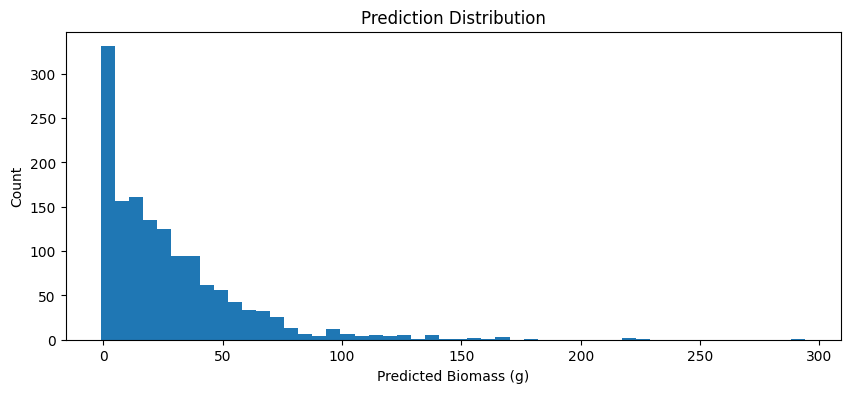

High clip threshold: 164.43468


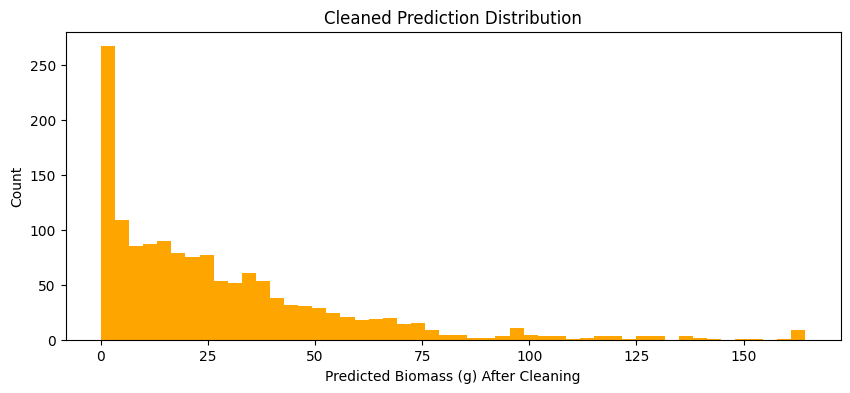

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# A. Analyze prediction distribution
# ---------------------------
print("Prediction stats:")
print("min:", preds.min())
print("max:", preds.max())
print("mean:", preds.mean())
print("std:", preds.std())

plt.figure(figsize=(10,4))
plt.hist(preds, bins=50)
plt.title("Prediction Distribution")
plt.xlabel("Predicted Biomass (g)")
plt.ylabel("Count")
plt.show()

# ---------------------------
# B. Clip NEGATIVE predictions (biomass can't be < 0)
# ---------------------------
preds = np.clip(preds, 0, None)

# ---------------------------
# C. Handle extreme OUTLIERS
# Strategy:
#   - Compute 99.5th percentile
#   - Soft-limit anything above it
# ---------------------------
high_thresh = np.percentile(preds, 99.5)
print("High clip threshold:", high_thresh)

preds[preds > high_thresh] = high_thresh

plt.figure(figsize=(10,4))
plt.hist(preds, bins=50, color='orange')
plt.title("Cleaned Prediction Distribution")
plt.xlabel("Predicted Biomass (g) After Cleaning")
plt.ylabel("Count")
plt.show()



Prediction stats:
min: -0.9832297
max: 294.15387
mean: 27.518568
std: 29.92494


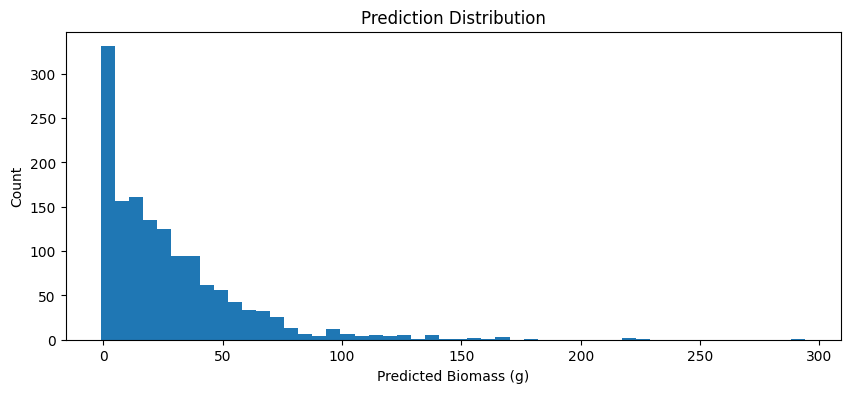

High clip threshold: 164.43468


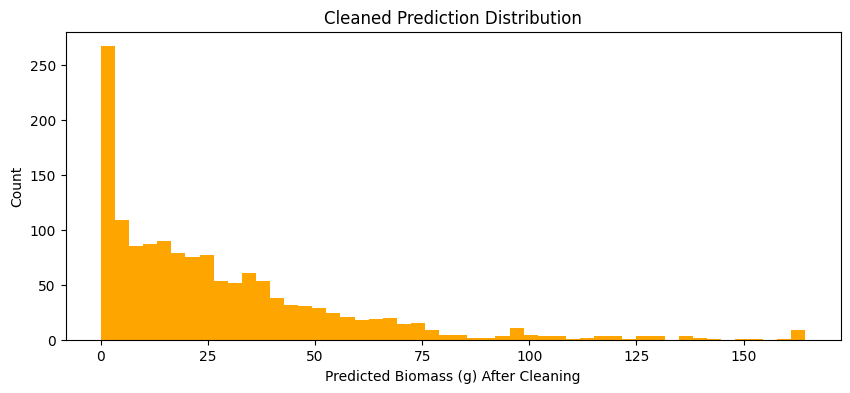

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# A. Analyze prediction distribution
# ---------------------------
print("Prediction stats:")
print("min:", preds.min())
print("max:", preds.max())
print("mean:", preds.mean())
print("std:", preds.std())

plt.figure(figsize=(10,4))
plt.hist(preds, bins=50)
plt.title("Prediction Distribution")
plt.xlabel("Predicted Biomass (g)")
plt.ylabel("Count")
plt.show()

# ---------------------------
# B. Clip NEGATIVE predictions (biomass can't be < 0)
# ---------------------------
preds = np.clip(preds, 0, None)

# ---------------------------
# C. Handle extreme OUTLIERS
# Strategy:
#   - Compute 99.5th percentile
#   - Soft-limit anything above it
# ---------------------------
high_thresh = np.percentile(preds, 99.5)
print("High clip threshold:", high_thresh)

preds[preds > high_thresh] = high_thresh

plt.figure(figsize=(10,4))
plt.hist(preds, bins=50, color='orange')
plt.title("Cleaned Prediction Distribution")
plt.xlabel("Predicted Biomass (g) After Cleaning")
plt.ylabel("Count")
plt.show()

